# Семинар 5 по РТЦиС

Задание 1 Полиномиальная аппроксимация, работа с внешними БД

In [283]:
import numpy as np
import matplotlib.pyplot as plt
pi = 3.1415

In [284]:
Data = open("circuit1.txt",'r', encoding="utf-8")
text = Data.read()
print(text)
A = np.array(text.split())          #Надеялся сразу создать массив, не получилось 😭
                                    #Когда преступление неясно, наказание должно быть нестрогим.
N = len(A)//2                       #Чтобы было удобнее нужно считывать из MicroCap данные по-отдельности
I = list(range(0,N,1))
V = list(range(0,N,1))
for i in range(len(A)):
    if i%2==0:
        V[i//2]=float(A[i])
    else:
        I[i//2]=float(A[i])
print("V: ", V)
print("I: ", I)

   0.0000000  0.0000000
   0.2999988  0.0000001
   0.5964858  0.0003514
   0.7521196  0.0147931
   0.8100927  0.0389915
   0.8523028  0.0647699
   0.8888788  0.0911122
   0.9225842  0.1177416
   0.9545549  0.1445445
   0.9853658  0.1714634
   1.0153492  0.1984651


V:  [0.0, 0.2999988, 0.5964858, 0.7521196, 0.8100927, 0.8523028, 0.8888788, 0.9225842, 0.9545549, 0.9853658, 1.0153492]
I:  [0.0, 1e-07, 0.0003514, 0.0147931, 0.0389915, 0.0647699, 0.0911122, 0.1177416, 0.1445445, 0.1714634, 0.1984651]


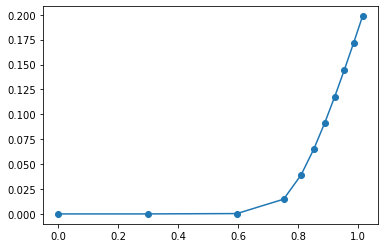

In [285]:
plt.plot(V,I)
plt.scatter(V,I)

[ 0.75293108 -0.33396843 -0.46194918  0.23492973]
        3         2
0.7529 x - 0.334 x - 0.4619 x + 0.2349


C:\Anaconda\lib\site-packages\IPython\core\interactiveshell.py:3369: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


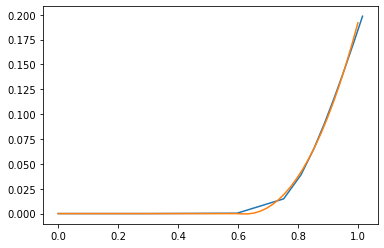

In [291]:
z=np.polyfit(V[2:11:3],I[2:11:3],3) #Подгонка полинома 3 степени
print(z) # Отображение z в виде массива , Высокий коэффициент 3, низкий коэффициент 1
p=np.poly1d(z) # Преобразовать z в полином
print(p) # Результат
plt.plot(V,I)
Vapr = np.linspace(0, 1, 50)
def Iaprtest(Vapr):
    return np.piecewise(Vapr, [Vapr < 0.6, Vapr >= 0.6], [0,p])
plt.plot(Vapr,Iaprtest(Vapr)) #Истинного самурая отличает снисходительность. Или, если сказать иначе, милосердие.

Второй способ

In [287]:
Vmatr = np.array([[V[5]**2, V[5],1],[V[3]**2, V[3], 1],[V[2]**2, V[2], 1]])
Imatr = np.array( [I[5],I[3],I[2]] )
print(Vmatr)
a, b, c = np.linalg.solve(Vmatr, Imatr)   
print(a,b,c, sep="  ")

[[0.72642006 0.8523028  1.        ]
 [0.56568389 0.7521196  1.        ]
 [0.35579531 0.5964858  1.        ]]
1.587311531607279  -2.047864077798926  0.6571152449146895


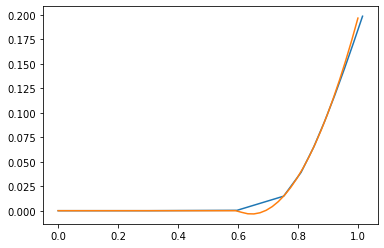

In [288]:
def Iapr(Vapr):
        return (a*(Vapr**2)+b*Vapr+c) * (Vapr > 0.6)
plt.plot(V,I)
plt.plot(Vapr,Iapr(Vapr))

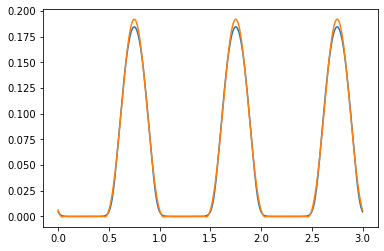

In [289]:
t = np.linspace(0, 3, 1000)
fi = pi
def U0(t):
    Amp = 0.3
    return Amp*np.sin(2*pi*t+fi)+0.7
Data2 = open("circuit2.txt",'r', encoding="utf-8")             #Нужно было сразу сделать разделение на два массива, как функцию
text2 = Data2.read()
A2 = np.array(text2.split())         
N2 = len(A2)//2
time = list(range(0,N2,1))
Itime = list(range(0,N2,1))
for i in range(len(A2)):
    if i%2==0:
        time[i//2]=float(A2[i])
    else:
        Itime[i//2]=float(A2[i])
plt.plot(time,Itime)
plt.plot(t, Iaprtest(U0(t)))